#Assignment 1

##SMS Spam Classifier

Objective: Build a binary text classifier to identify whether an incoming SMS is "Spam" or "Ham" (legitimate).

Dataset Link https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Task 1:

Clean the text by removing punctuation, converting to lowercase, and dropping common stop words.

In [ ]:
import requests as req
import pandas as pd
import numpy as np

#url = req.get("https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset")
#open("spam.csv", "wb").write(url.content)
df = pd.read_csv("/content/spam.csv", encoding = "latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.drop(axis=1,columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

nltk.download('stopwords')

# Initialize stemmer and stopwords
ps = PorterStemmer()
stopwords_set = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Remove stopwords and apply stemming (optional, but good for classification)
    text = ' '.join([ps.stem(word) for word in text.split() if word not in stopwords_set])
    return text

df['cleaned_v2'] = df['v2'].apply(clean_text)

In [ ]:
display(df[['v2', 'cleaned_v2']].head())

,v2,cleaned_v2
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


Task 2:

Convert texts into numerical formats using CountVectorizer or TfidfVectorizer from scikit-learn.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['cleaned_v2'])

print('TfidfVectorizer Shape:', X_tfidf.shape)
print('TfidfVectorizer features:\n', tfidf.get_feature_names_out()[:10])

TfidfVectorizer Shape: (5572, 8038)
TfidfVectorizer features:
 ['008704050406' '0089mi' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089']


Task 3:

Split data into an 80/20 train-test ratio.Train a Naive Bayes or Logistic Regression classifier.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Define features (X) and target (y)
X = X_tfidf  # Using TF-IDF features
y = df['v1'] # 'v1' contains 'ham' or 'spam' labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 4457 samples
Test set size: 1115 samples


In [ ]:
# Train Logistic Regression Classifier
lr_model = LogisticRegression(solver='liblinear', random_state=42)
lr_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Task 4:

Evaluate performance using an F1-score and a Confusion Matrix.


--- Logistic Regression Performance ---
F1-Score: 0.7552

Classification Report:
               precision    recall  f1-score   support

         ham       0.94      1.00      0.97       966
        spam       0.99      0.61      0.76       149

    accuracy                           0.95      1115
   macro avg       0.97      0.80      0.86      1115
weighted avg       0.95      0.95      0.94      1115



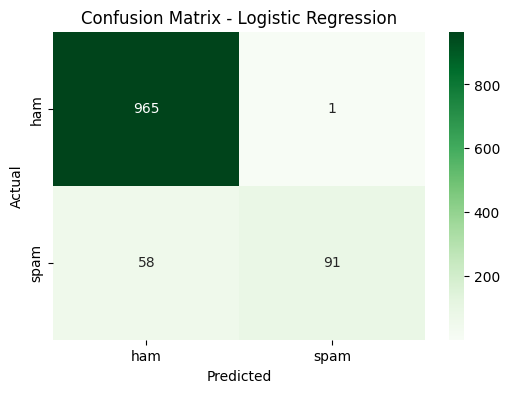

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions with Logistic Regression
lr_y_pred = lr_model.predict(X_test)

# Evaluate Logistic Regression
lr_f1 = f1_score(y_test, lr_y_pred, pos_label='spam')
lr_cm = confusion_matrix(y_test, lr_y_pred, labels=['ham', 'spam'])

print("\n--- Logistic Regression Performance ---")
print(f"F1-Score: {lr_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Assignment 2:

##IMDB Movie Review Sentiment Analysis

Objective: Classify movie reviews as positive or negative using traditional machine learning algorithms.

Dataset Link: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Now that the dataset is downloaded and unzipped, let's load it into a pandas DataFrame and perform some initial EDA.

Task 1:

Perform exploratory data analysis (EDA) to check for class imbalances.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the IMDB dataset
imdb_df = pd.read_csv('/content/IMDB Dataset.csv',encoding="latin-1")
print("IMDB Dataset loaded successfully.")
display(imdb_df.head())

IMDB Dataset loaded successfully.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Sentiment distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


/tmp/ipykernel_1022/2618225902.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=imdb_df, palette='viridis')


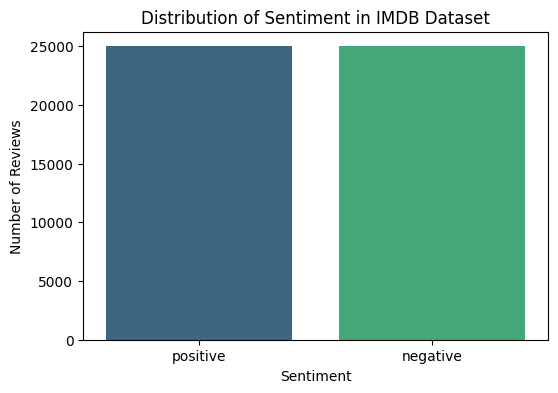

In [ ]:
print('Sentiment distribution:\n', imdb_df['sentiment'].value_counts())

# Visualize the sentiment distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=imdb_df, palette='viridis')
plt.title('Distribution of Sentiment in IMDB Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

Task 2:

Tokenize the reviews and apply Stemming or Lemmatization via the nltk library.

In [ ]:
# Demonstrate on a small sample to avoid long processing time
sample_size = 100
sampled_df = imdb_df.head(sample_size).copy()
sampled_df['cleaned_review'] = sampled_df['review'].apply(clean_and_stem_review)

print(f'Original Review vs. Cleaned Review Sample (first {sample_size} reviews):')
display(sampled_df[['review', 'cleaned_review']].head())

Original Review vs. Cleaned Review Sample (first 100 reviews):


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other review ha mention that after ...
1,A wonderful little production. <br /><br />The...,a wonder littl product the film techniqu is ve...
2,I thought this was a wonderful way to spend ti...,i thought thi wa a wonder way to spend time on...
3,Basically there's a family where a little boy ...,basic there a famili where a littl boy jake th...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love in the time of money is a v...


### Re-defining Cleaning and Stemming for the full IMDB dataset

Since the previous function definition was removed, and applying it to the full dataset caused an interruption, I'm re-adding the necessary code. Please be aware that processing the entire 50,000 reviews can still take a significant amount of time.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string
import re # Import re for regex operations

nltk.download('punkt') # Download the punkt tokenizer for word_tokenize
nltk.download('punkt_tab') # Download the punkt_tab resource for word_tokenize

ps_imdb = PorterStemmer() # Initialize a new Porter Stemmer for IMDB reviews

def clean_and_stem_review(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags (common in IMDB dataset)
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Tokenize the text
    tokens = word_tokenize(text)
    # Apply stemming, keeping only alphabetic words
    stemmed_tokens = [ps_imdb.stem(word) for word in tokens if word.isalpha()]
    return ' '.join(stemmed_tokens)

print("Applying cleaning and stemming to the full IMDB dataset. This may take a while...")
imdb_df['cleaned_review'] = imdb_df['review'].apply(clean_and_stem_review)
print("Cleaning and stemming complete.")
display(imdb_df[['review', 'cleaned_review']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Applying cleaning and stemming to the full IMDB dataset. This may take a while...
Cleaning and stemming complete.


,review,cleaned_review
0,One of the other reviewers has mentioned that ...,one of the other review ha mention that after ...
1,A wonderful little production. <br /><br />The...,a wonder littl product the film techniqu is ve...
2,I thought this was a wonderful way to spend ti...,i thought thi wa a wonder way to spend time on...
3,Basically there's a family where a little boy ...,basic there a famili where a littl boy jake th...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love in the time of money is a v...


### TF-IDF Representation with N-gram Range (1, 2)

Task 3:

Use TF-IDF text representation with an n-gram range of (1, 2) to capture two-word phrases.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with n-gram range (1, 2)
tfidf_imdb = TfidfVectorizer(ngram_range=(1, 2))

# Apply TF-IDF to the cleaned IMDB reviews
X_imdb_tfidf = tfidf_imdb.fit_transform(imdb_df['cleaned_review'])

print('TF-IDF Vectorizer Shape for IMDB dataset:', X_imdb_tfidf.shape)
print('TF-IDF features (first 10) for IMDB dataset:\n', tfidf_imdb.get_feature_names_out()[:10])

TF-IDF Vectorizer Shape for IMDB dataset: (50000, 2355672)
TF-IDF features (first 10) for IMDB dataset:
 ['aa' 'aa and' 'aa antic' 'aa as' 'aa cultrehab' 'aa doctor' 'aa group'
 'aa is' 'aa jaega' 'aa level']


Task 4:

Train a Linear Support Vector Machine (LinearSVC) or Random Forest model.Test with custom text snippets written by yourself to observe real-time predictions.Compute Metrics

### Preparing Data for Model Training

Before training, the `sentiment` labels need to be converted into a numerical format (e.g., 0 for negative, 1 for positive). Then, the data will be split into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Convert sentiment labels to numerical (0 for negative, 1 for positive)
y_imdb = imdb_df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

# Split the data into training and testing sets
X_imdb_train, X_imdb_test, y_imdb_train, y_imdb_test = train_test_split(
    X_imdb_tfidf, y_imdb, test_size=0.2, random_state=42, stratify=y_imdb
)

print(f"IMDB Training set size: {X_imdb_train.shape[0]} samples")
print(f"IMDB Test set size: {X_imdb_test.shape[0]} samples")

IMDB Training set size: 40000 samples
IMDB Test set size: 10000 samples


### Training a Linear Support Vector Machine (LinearSVC) Model

LinearSVC is chosen for its effectiveness with large datasets and sparse feature matrices like TF-IDF.

In [ ]:
from sklearn.svm import LinearSVC

# Initialize and train the LinearSVC model
linear_svc_model = LinearSVC(random_state=42)
linear_svc_model.fit(X_imdb_train, y_imdb_train)

print("LinearSVC model trained successfully on IMDB dataset.")

LinearSVC model trained successfully on IMDB dataset.


### Evaluating Model Performance

The model's performance will be evaluated using F1-score and a confusion matrix to understand its accuracy, precision, and recall.


--- LinearSVC Performance on IMDB Dataset ---
F1-Score: 0.9152

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91      5000
           1       0.91      0.92      0.92      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



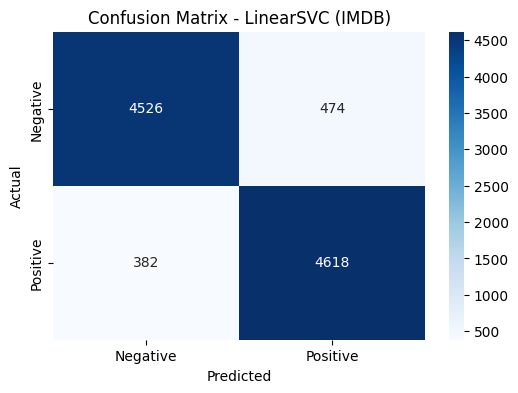

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
linear_svc_y_pred = linear_svc_model.predict(X_imdb_test)

# Evaluate LinearSVC performance
linear_svc_f1 = f1_score(y_imdb_test, linear_svc_y_pred)
linear_svc_cm = confusion_matrix(y_imdb_test, linear_svc_y_pred)

print("\n--- LinearSVC Performance on IMDB Dataset ---")
print(f"F1-Score: {linear_svc_f1:.4f}")
print("\nClassification Report:\n", classification_report(y_imdb_test, linear_svc_y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(linear_svc_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - LinearSVC (IMDB)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Testing with Custom Text Snippets

This function will allow you to input custom movie reviews and get real-time sentiment predictions from the trained model.

In [ ]:
def predict_sentiment(text):
    # Clean and stem the custom text using the same function as for the dataset
    cleaned_text = clean_and_stem_review(text)

    # Transform the cleaned text using the trained TF-IDF vectorizer
    text_tfidf = tfidf_imdb.transform([cleaned_text])

    # Make prediction using the trained LinearSVC model
    prediction = linear_svc_model.predict(text_tfidf)

    # Interpret the prediction
    if prediction[0] == 1:
        return "Positive"
    else:
        return "Negative"

# Example custom tests
custom_review_1 = "This movie was absolutely fantastic! I loved every minute of it. The acting was superb."
custom_review_2 = "What a terrible waste of time. The plot was boring and the characters were unconvincing."
custom_review_3 = "It had some good moments, but overall it was just average."

print(f"Review 1: '{custom_review_1}'\nPrediction: {predict_sentiment(custom_review_1)}\n")
print(f"Review 2: '{custom_review_2}'\nPrediction: {predict_sentiment(custom_review_2)}\n")
print(f"Review 3: '{custom_review_3}'\nPrediction: {predict_sentiment(custom_review_3)}\n")

Review 1: 'This movie was absolutely fantastic! I loved every minute of it. The acting was superb.'
Prediction: Positive

Review 2: 'What a terrible waste of time. The plot was boring and the characters were unconvincing.'
Prediction: Negative

Review 3: 'It had some good moments, but overall it was just average.'
Prediction: Negative



#Assignment 3

##Fake News Detector

Objective: Identify whether a news article contains real or fabricated information.

Dataset link: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

Dataset separated in two files:

1. Fake.csv (23502 fake news article)
2. True.csv (21417 true news article)

In [ ]:
import pandas as pd
import numpy as np
fake_csv=pd.read_csv('/content/Fake.csv')
true_csv=pd.read_csv("/content/True.csv")


Task 1:

Merge the true and fake datasets, adding a target binary column (0 for real, 1 for fake).

In [ ]:
fake_csv['target'] = 1
true_csv['target'] = 0
df = pd.concat([fake_csv, true_csv]).sample(frac=1).reset_index(drop=True)
df.head()

,title,text,subject,date,target
0,Trump BASHES Obama With Hostile Fiction For N...,There are a lot of things citizens of the Unit...,News,"February 20, 2016",1
1,Exclusive: Billionaire Republican donors urge ...,NEW YORK (Reuters) - A group of at least six w...,politicsNews,"July 28, 2016",0
2,Trump BLOCKS Stephen King After Writer Delive...,Acclaimed horror writer Stephen King is no fan...,News,"June 13, 2017",1
3,Foreign Diplomats Scared Sh*tless Over The Id...,"As we know, the final United Nations General A...",News,"September 21, 2016",1
4,Puerto Rico needs restructuring to avoid casca...,NEW YORK/SAN JUAN (Reuters) - U.S. Treasury co...,politicsNews,"February 25, 2016",0


Task 2:

Concatenate the article title and text fields into a single text feature.

In [ ]:
df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df.head()


,title,text,subject,date,target,full_text
0,Trump BASHES Obama With Hostile Fiction For N...,There are a lot of things citizens of the Unit...,News,"February 20, 2016",1,Trump BASHES Obama With Hostile Fiction For N...
1,Exclusive: Billionaire Republican donors urge ...,NEW YORK (Reuters) - A group of at least six w...,politicsNews,"July 28, 2016",0,Exclusive: Billionaire Republican donors urge ...
2,Trump BLOCKS Stephen King After Writer Delive...,Acclaimed horror writer Stephen King is no fan...,News,"June 13, 2017",1,Trump BLOCKS Stephen King After Writer Delive...
3,Foreign Diplomats Scared Sh*tless Over The Id...,"As we know, the final United Nations General A...",News,"September 21, 2016",1,Foreign Diplomats Scared Sh*tless Over The Id...
4,Puerto Rico needs restructuring to avoid casca...,NEW YORK/SAN JUAN (Reuters) - U.S. Treasury co...,politicsNews,"February 25, 2016",0,Puerto Rico needs restructuring to avoid casca...


Task 3:

Transform text using TF-IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency
X_tfidf_fake_news = tfidf_vectorizer.fit_transform(df['full_text'])

print('TF-IDF Vectorizer Shape:', X_tfidf_fake_news.shape)
print('First 10 TF-IDF features:', tfidf_vectorizer.get_feature_names_out()[:10])

TF-IDF Vectorizer Shape: (44898, 5000)
First 10 TF-IDF features: ['00' '000' '10' '100' '11' '12' '120' '13' '14' '15']


Task 4:

Train a PassiveAggressiveClassifier—known to perform exceptionally well on text tracking shifting trends.Monitor accuracy over cross-validation folds.Compute relevant metrics

Fake News Training set size: 35918 samples
Fake News Test set size: 8980 samples

Cross-validation accuracy scores: [0.9935412  0.99621381 0.99510022 0.99487694 0.99476556]
Mean CV accuracy: 0.9949

--- PassiveAggressiveClassifier Performance ---
Accuracy: 0.9951
F1-Score: 0.9953

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      4284
           1       1.00      0.99      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



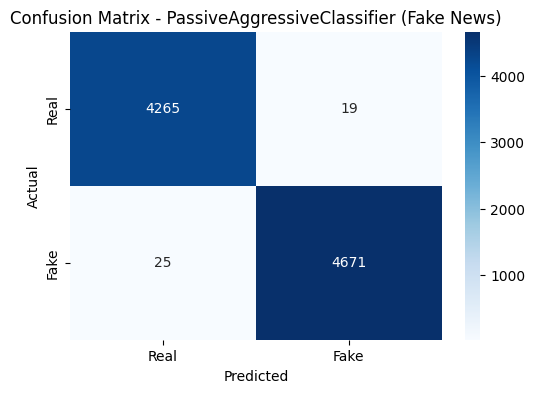

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
X_fake_news = X_tfidf_fake_news # Using TF-IDF features from previous step
y_fake_news = df['target'] # 'target' contains 0 for real, 1 for fake

# Split the data into training and testing sets
X_train_fn, X_test_fn, y_train_fn, y_test_fn = train_test_split(X_fake_news, y_fake_news, test_size=0.2, random_state=42, stratify=y_fake_news)

print(f"Fake News Training set size: {X_train_fn.shape[0]} samples")
print(f"Fake News Test set size: {X_test_fn.shape[0]} samples")

# Train PassiveAggressiveClassifier
pac = PassiveAggressiveClassifier(max_iter=50, random_state=42, early_stopping=True, n_iter_no_change=5)
pac.fit(X_train_fn, y_train_fn)

# Cross-validation
cv_scores = cross_val_score(pac, X_fake_news, y_fake_news, cv=5, scoring='accuracy')
print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")

# Make predictions
y_pred_fn = pac.predict(X_test_fn)

# Evaluate performance
accuracy_fn = accuracy_score(y_test_fn, y_pred_fn)
f1_fn = f1_score(y_test_fn, y_pred_fn)
cm_fn = confusion_matrix(y_test_fn, y_pred_fn)

print("\n--- PassiveAggressiveClassifier Performance ---")
print(f"Accuracy: {accuracy_fn:.4f}")
print(f"F1-Score: {f1_fn:.4f}")
print("\nClassification Report:\n", classification_report(y_test_fn, y_pred_fn))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm_fn, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix - PassiveAggressiveClassifier (Fake News)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()